<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        DBSCAN y Clustering Basado en Densidad
      </h1>
      <p style="margin: 6px 0 0 0; color: #1e3a8a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Programación para Ciencia de Datos
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #1e3a8a; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 10
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Data%20Science%20programming/10%20-%20Clustering/04_DBSCAN_Clustering.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## 1. Clustering Basado en Densidad: La Idea Central 🧠

K-Means (cuaderno 02) agrupa según la cercanía a un centroide, y el clustering jerárquico (cuaderno 03) según una secuencia de fusiones — ambos, en el fondo, terminan asignando **todo** punto a algún clúster y ambos favorecen implícitamente formas convexas o aproximadamente esféricas. **DBSCAN** (*Density-Based Spatial Clustering of Applications with Noise*) parte de una idea completamente distinta: un clúster es una región del espacio de características con **alta densidad de puntos**, separada de otras regiones densas por zonas de **baja densidad**.

Esta idea de "densidad y conectividad" le da a DBSCAN tres ventajas importantes frente a K-Means y al clustering jerárquico:

1. **No necesita conocer el número de clústeres de antemano** — el propio algoritmo lo determina.
2. **Puede encontrar clústeres de forma arbitraria**, no solo agrupaciones convexas/esféricas.
3. **Puede identificar y separar explícitamente valores atípicos (*outliers*)**, en lugar de forzar a que cada punto pertenezca a algún clúster.

<div align="center">
  <img src="images/dbscan.png" width="550" alt="Puntos núcleo, borde y ruido en DBSCAN" style="border-radius:8px; box-shadow: 0 4px 6px rgba(0,0,0,0.15); margin: 10px 0;"/>
  <p style="font-size: 0.85em; color: #64748b;">
    <i>Figura: DBSCAN clasifica cada punto como núcleo, borde o ruido según cuántos vecinos tiene dentro de un radio <code>eps</code>.</i>
  </p>
</div>

---
## Configuración del Entorno de Trabajo 🛠️

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, sys, urllib.request
import warnings
warnings.filterwarnings('ignore')

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (8.5, 4.5)
plt.rcParams['font.size'] = 10

def load_dataset(filename, module_folder="10 - Clustering"):
    local_path = os.path.join(os.getcwd(), "data", filename)
    if os.path.exists(local_path):
        return local_path

    parent_path = os.path.join(os.getcwd(), "..", module_folder, "data", filename)
    if os.path.exists(parent_path):
        return parent_path

    raw_url = f"https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/Data%20Science%20programming/{module_folder.replace(' ', '%20')}/data/{filename}"
    os.makedirs("data", exist_ok=True)
    target_path = os.path.join("data", filename)
    if not os.path.exists(target_path):
        urllib.request.urlretrieve(raw_url, target_path)
    return target_path

print("🚀 Entorno configurado exitosamente para el Módulo 10: Clustering.")

🚀 Entorno configurado exitosamente para el Módulo 10: Clustering.


---
## 2. Puntos Núcleo, Borde y Ruido 🔍

DBSCAN se parametriza con dos valores:

* **`eps`** ($\varepsilon$): el radio de vecindad alrededor de cada punto.
* **`min_samples`** (también llamado *MinPts* en la literatura original): el número mínimo de puntos (incluyéndose a sí mismo) que deben encontrarse dentro de ese radio para que un punto se considere denso.

Con estos dos parámetros, **todo punto del dataset cae en exactamente una de tres categorías**:

* **Punto núcleo (*core point*):** tiene al menos `min_samples` puntos (incluyéndose a sí mismo) dentro de un radio `eps`. Tras ajustar el modelo, scikit-learn expone sus índices en `model.core_sample_indices_`.
* **Punto borde (*border point*):** tiene menos de `min_samples` vecinos dentro de `eps`, pero cae dentro del radio `eps` de algún punto núcleo — es decir, pertenece a un clúster por "adopción", aunque él mismo no sea suficientemente denso.
* **Punto de ruido (*noise point*):** no es núcleo ni borde de ningún clúster. Scikit-learn le asigna la etiqueta especial `-1`.

### Esquema del Algoritmo

1. Partir de un punto `p` no visitado cualquiera y recuperar todos los puntos **densamente alcanzables** desde `p` (siguiendo cadenas de punto-núcleo a punto-núcleo dentro de `eps`).
2. Si `p` resulta ser un punto núcleo, este conjunto forma un **nuevo clúster**; si no, `p` se marca (por ahora) como ruido — podría terminar siendo un punto borde de un clúster descubierto más adelante.
3. Repetir el proceso para cada punto no visitado hasta cubrir todo el dataset.

A diferencia de K-Means, DBSCAN **no itera** entre asignación y actualización de centroides — es, en esencia, un único recorrido de vecindades sobre el dataset.

---
## 3. Ajustando DBSCAN con Scikit-Learn ⚡

Reutilizamos el dataset `mall_customers.csv` (cuaderno 02) con las mismas dos características (`Annual_Income_k`, `Spending_Score`), en su escala original — el significado de `eps` (una distancia) depende directamente de la escala de los datos, así que a lo largo de este cuaderno seremos explícitos sobre si trabajamos con las variables originales o estandarizadas.

In [2]:
file_mall = load_dataset('mall_customers.csv')
df_mall = pd.read_csv(file_mall)

X = df_mall[['Annual_Income_k', 'Spending_Score']].values

print(f"Dimensiones del dataset: {df_mall.shape}")
df_mall.head()

Dimensiones del dataset: (200, 5)


,CustomerID,Gender,Age,Annual_Income_k,Spending_Score
0,1,Male,41,20,18
1,2,Female,69,29,24
2,3,Female,28,38,76
3,4,Female,66,25,25
4,5,Male,25,64,62


In [3]:
from sklearn.cluster import DBSCAN

dbscan_model = DBSCAN(eps=24, min_samples=20)
y_predict = dbscan_model.fit_predict(X)

print("Número de outliers (ruido):", (y_predict == -1).sum())
print("Número de clústeres encontrados:", len(set(y_predict)) - (1 if -1 in y_predict else 0))
print("Distribución de puntos por etiqueta de clúster:")
print(pd.Series(y_predict).value_counts().sort_index())

Número de outliers (ruido): 0
Número de clústeres encontrados: 1
Distribución de puntos por etiqueta de clúster:
0    200
Name: count, dtype: int64


<Figure size 850x450 with 0 Axes>

Text(0.5, 1.0, 'DBSCAN (eps=24, min_samples=20): Clientes del Centro Comercial')

Text(0.5, 0, 'Annual Income (k$)')

Text(0, 0.5, 'Spending Score (1-100)')

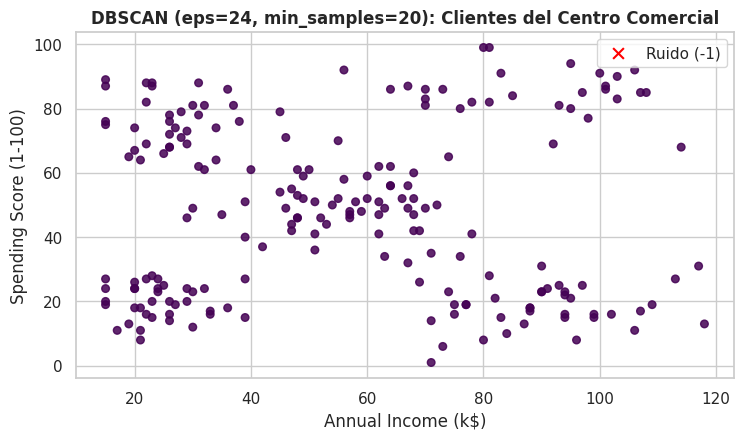

In [4]:
plt.figure()
mask_noise = y_predict == -1
plt.scatter(X[~mask_noise, 0], X[~mask_noise, 1], c=y_predict[~mask_noise], cmap='viridis', s=30, alpha=0.85)
plt.scatter(X[mask_noise, 0], X[mask_noise, 1], c='red', marker='x', s=60, label='Ruido (-1)')
plt.title("DBSCAN (eps=24, min_samples=20): Clientes del Centro Comercial", fontweight='bold')
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

`model.core_sample_indices_` guarda los índices de todos los puntos núcleo — el resto de los puntos que sí obtuvieron una etiqueta de clúster (distinta de `-1`) son puntos borde. Nótese la diferencia fundamental frente a K-Means (cuaderno 02): aquí **no todo punto es forzado a pertenecer a un clúster** — algunos, marcados con `-1`, quedan explícitamente fuera de cualquier grupo por no tener suficiente densidad de vecinos a su alrededor ni estar cerca de ningún punto que sí la tenga.

---
## 4. Seleccionando `eps` y `min_samples` 🎯

A diferencia de $K$ en K-Means, `eps` y `min_samples` no tienen una interpretación tan directa — y elegirlos únicamente "a ojo" resulta costoso, especialmente en datasets grandes o de alta dimensionalidad. Dos estrategias complementarias:

### a) Gráfico de Distancia al k-ésimo Vecino (*k-distance plot*)

Fijamos `min_samples` y, para cada punto, calculamos la distancia a su `min_samples`-ésimo vecino más cercano. Los puntos núcleo/borde deberían tener una distancia pequeña y relativamente similar a este vecino, mientras que los puntos de ruido muestran una distancia mucho mayor — por lo que, al ordenar estas distancias de menor a mayor, suele aparecer un **codo** claramente visible. Un buen valor de `eps` está, aproximadamente, en ese codo.

<Figure size 850x450 with 0 Axes>

Text(0.5, 1.0, 'Gráfico k-distance para min_samples=20')

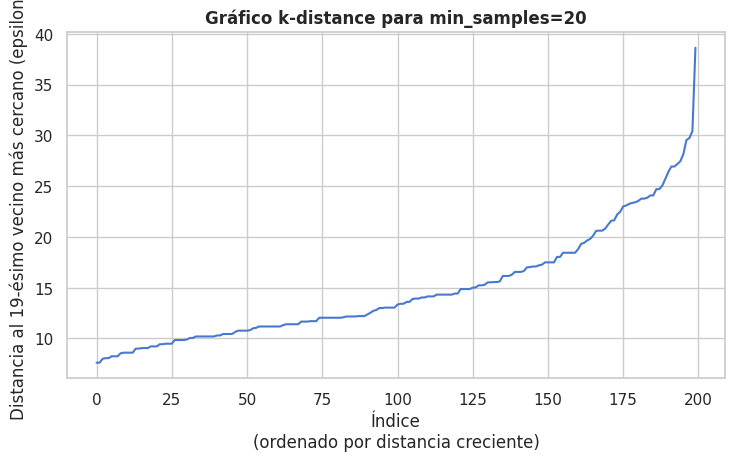

In [5]:
from sklearn.neighbors import NearestNeighbors

def plot_epsilon(df, min_samples):
    fitted_neighbors = NearestNeighbors(n_neighbors=min_samples).fit(df)
    distances, indices = fitted_neighbors.kneighbors(df)
    dist_to_nth_nearest_neighbor = distances[:, -1]
    plt.plot(np.sort(dist_to_nth_nearest_neighbor))
    plt.xlabel("Índice\n(ordenado por distancia creciente)")
    plt.ylabel(f"Distancia al {min_samples-1}-ésimo vecino más cercano (epsilon)")

plt.figure()
plot_epsilon(X, min_samples=20)
plt.title("Gráfico k-distance para min_samples=20", fontweight='bold')
plt.show()

### b) Búsqueda en Rejilla Maximizando el Coeficiente de Silueta

También podemos (o, mejor aún, en combinación con el gráfico anterior) recorrer una pequeña rejilla de combinaciones `min_samples`/`eps` y quedarnos con la que maximiza el **coeficiente de silueta** (`silhouette_score`, que estudiaremos en detalle en el cuaderno 05) — una métrica de evaluación interna que no requiere etiquetas verdaderas.

In [6]:
from sklearn.metrics import silhouette_score

best = None
for ms in range(5, 24):
    for ep in range(15, 30):
        labels = DBSCAN(min_samples=ms, eps=ep).fit(X).labels_
        if len(set(labels)) < 2:
            continue  # silhouette_score exige al menos 2 clústeres
        score = silhouette_score(X, labels)
        if best is None or score > best[-1]:
            best = (ms, ep, score)

print(f"Mejor combinación encontrada -> min_samples={best[0]}, eps={best[1]}, silueta={best[2]:.3f}")

Mejor combinación encontrada -> min_samples=23, eps=17, silueta=0.499


Ambos enfoques son heurísticos, no exactos: el codo del gráfico *k-distance* puede ser sutil o ambiguo, y maximizar la silueta favorece particiones convexas y bien separadas (la misma limitación de la silueta que discutiremos en el cuaderno 05). En la práctica, es buena idea combinar ambos con inspección visual y conocimiento del dominio, en lugar de confiar ciegamente en un único número.

---
## 5. La Gran Ventaja de DBSCAN: Formas Arbitrarias 🌙

Para hacer tangible la primera ventaja mencionada en la sección 1, generamos un dataset sintético no convexo (`make_moons`: dos "medias lunas" entrelazadas) y comparamos, lado a lado, un ajuste de K-Means contra un ajuste de DBSCAN.

Text(0.5, 1.0, 'K-Means (k=2): Corta las Medias Lunas por la Mitad')

Text(0.5, 1.0, 'DBSCAN: Recupera las Dos Medias Lunas Correctamente')

Text(0.5, 0, 'Característica 1')

Text(0, 0.5, 'Característica 2')

Text(0.5, 0, 'Característica 1')

Text(0, 0.5, 'Característica 2')

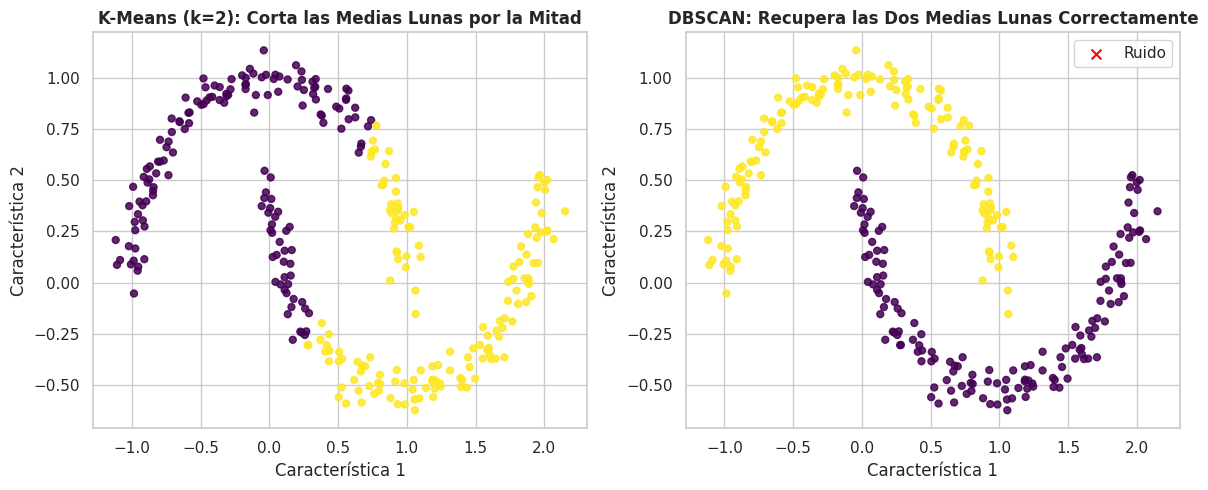

In [7]:
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans

X_moons, _ = make_moons(n_samples=300, noise=0.06, random_state=0)

kmeans_moons = KMeans(n_clusters=2, n_init=10, random_state=0)
labels_kmeans = kmeans_moons.fit_predict(X_moons)

dbscan_moons = DBSCAN(eps=0.2, min_samples=5)
labels_dbscan = dbscan_moons.fit_predict(X_moons)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=labels_kmeans, cmap='viridis', s=25, alpha=0.85)
axes[0].set_title("K-Means (k=2): Corta las Medias Lunas por la Mitad", fontweight='bold')

mask = labels_dbscan == -1
axes[1].scatter(X_moons[~mask, 0], X_moons[~mask, 1], c=labels_dbscan[~mask], cmap='viridis', s=25, alpha=0.85)
axes[1].scatter(X_moons[mask, 0], X_moons[mask, 1], c='red', marker='x', s=50, label='Ruido')
axes[1].set_title("DBSCAN: Recupera las Dos Medias Lunas Correctamente", fontweight='bold')
axes[1].legend()

for ax in axes:
    ax.set_xlabel("Característica 1")
    ax.set_ylabel("Característica 2")

plt.tight_layout()
plt.show()

El resultado ilustra exactamente la limitación de K-Means discutida en el cuaderno 02: al optimizar distancia a un centroide, K-Means **no puede** representar una forma de media luna con un único clúster — la corta arbitrariamente por la mitad. DBSCAN, en cambio, sigue la conectividad de densidad a lo largo de cada media luna y las recupera correctamente, siempre que `eps` esté bien calibrado para la escala de este dataset en particular.

---
## 6. Puntos Clave y Limitaciones ⚠️

### Puntos Clave

* **Agrupa relaciones no lineales:** puede encontrar clústeres de forma arbitraria, no solo agrupaciones convexas.
* **No requiere fijar $K$ de antemano** — el número de clústeres emerge del propio proceso de expansión por densidad.
* **Robusto frente a valores atípicos:** los separa explícitamente como ruido (etiqueta `-1`) en lugar de forzarlos dentro de algún clúster.
* **No garantiza que todo punto quede agrupado** — algunos pueden quedar como ruido, a diferencia de K-Means o del clustering jerárquico, donde cada observación siempre recibe una etiqueta de clúster.

### Limitaciones a Tener en Cuenta

* **Sensibilidad a `eps`/`min_samples`:** un `eps` demasiado pequeño produce exceso de ruido; uno demasiado grande fusiona clústeres que deberían estar separados.
* **Dificultad con densidades muy distintas:** DBSCAN usa un único `eps` global, por lo que le cuesta separar correctamente clústeres densos y clústeres dispersos que coexisten en el mismo dataset (para ese escenario existen variantes como HDBSCAN, fuera del alcance de este curso).
* **Costo de vecindad:** calcular vecinos dentro de `eps` para cada punto tiene un costo que crece con el tamaño del dataset y con la dimensionalidad de los datos.

---
##### 🛠️ Práctica 1: Sintonizando DBSCAN con Tres Características

**Objetivo:** Extender el análisis de segmentación de clientes agregando `Age` como tercera característica, seleccionar `eps` de forma sistemática (con el gráfico *k-distance*) y comparar el resultado frente al K-Means de 5 clústeres del cuaderno 02.

**Instrucciones:**
1. Construye `X3 = df_mall[['Age', 'Annual_Income_k', 'Spending_Score']].values` y estandarízalo con `StandardScaler` (import `sklearn.preprocessing.StandardScaler`) — guarda el resultado en `X3_scaled`.
2. Usa `plot_epsilon(X3_scaled, min_samples=10)` para generar el gráfico k-distance y elige, a partir del codo observado, un valor razonable de `eps` (en el espacio estandarizado, normalmente entre 0.3 y 1.0).
3. Ajusta `DBSCAN(eps=<tu_valor>, min_samples=10)` sobre `X3_scaled`.
4. Reporta cuántos clústeres se formaron y cuántos puntos quedaron marcados como ruido.
5. Calcula `silhouette_score` para tu resultado de DBSCAN (excluyendo o incluyendo el ruido, indica cuál elegiste y por qué) y compáralo con el de `KMeans(n_clusters=5)` sobre los mismos datos estandarizados. ¿Cuál algoritmo obtiene mejor silueta en este dataset? ¿Te sorprende el resultado dada la forma del dataset original (mayormente convexo)?

In [ ]:
# =========================================================================
# TU SOLUCIÓN: Práctica 1 - DBSCAN con Tres Características
# =========================================================================

# 1. Construir y estandarizar la matriz de características de 3 columnas
# from sklearn.preprocessing import StandardScaler
# X3 = df_mall[['Age', 'Annual_Income_k', 'Spending_Score']].values
# scaler3 = StandardScaler()
# X3_scaled = scaler3.fit_transform(X3)

# 2. Gráfico k-distance para elegir eps
# plt.figure()
# plot_epsilon(X3_scaled, min_samples=10)
# plt.show()

# 3. Ajustar DBSCAN con el eps elegido
# dbscan_p1 = DBSCAN(eps=..., min_samples=10)
# y_pred_p1 = dbscan_p1.fit_predict(X3_scaled)

# 4. Contar clústeres y ruido
# print(...)

# 5. Comparar silueta contra KMeans(n_clusters=5)
# kmeans_p1 = KMeans(n_clusters=5, n_init=10, random_state=42).fit(X3_scaled)
# print(silhouette_score(X3_scaled, y_pred_p1), silhouette_score(X3_scaled, kmeans_p1.labels_))

<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
from sklearn.preprocessing import StandardScaler

# 1. Construir y estandarizar
X3 = df_mall[['Age', 'Annual_Income_k', 'Spending_Score']].values
scaler3 = StandardScaler()
X3_scaled = scaler3.fit_transform(X3)

# 2. Gráfico k-distance
plt.figure()
plot_epsilon(X3_scaled, min_samples=10)
plt.title("k-distance con 3 características estandarizadas", fontweight='bold')
plt.show()
# Supongamos que el codo aparece alrededor de eps=0.75

# 3. Ajustar DBSCAN
dbscan_p1 = DBSCAN(eps=0.75, min_samples=10)
y_pred_p1 = dbscan_p1.fit_predict(X3_scaled)

# 4. Contar clústeres y ruido
n_clusters_p1 = len(set(y_pred_p1)) - (1 if -1 in y_pred_p1 else 0)
print(f"Clústeres encontrados: {n_clusters_p1}")
print(f"Puntos de ruido: {(y_pred_p1 == -1).sum()} de {len(y_pred_p1)}")

# 5. Comparar silueta (excluyendo el ruido, criterio habitual)
mask = y_pred_p1 != -1
sil_dbscan = silhouette_score(X3_scaled[mask], y_pred_p1[mask])

kmeans_p1 = KMeans(n_clusters=5, n_init=10, random_state=42)
labels_kmeans_p1 = kmeans_p1.fit_predict(X3_scaled)
sil_kmeans = silhouette_score(X3_scaled, labels_kmeans_p1)

print(f"Silueta DBSCAN (sin ruido): {sil_dbscan:.3f}")
print(f"Silueta KMeans (k=5):       {sil_kmeans:.3f}")
```

**Interpretación esperada:** con solo 3 características moderadamente correlacionadas y sin estructura no convexa marcada, es habitual que **K-Means iguale o incluso supere** a DBSCAN en silueta — la silueta favorece clústeres compactos y convexos, precisamente el tipo de estructura que K-Means está optimizando por construcción. Esto no significa que DBSCAN sea "peor": significa que este dataset en particular no muestra su ventaja principal (formas arbitrarias), la cual sí se hizo evidente en el ejemplo de `make_moons` de la sección 5. La elección del algoritmo debe basarse en la forma real de los datos, no únicamente en un número de silueta más alto.
</details>

---
### 7. Resumen y Conclusiones del Cuaderno 04 📌

1. **Densidad en Lugar de Centroides:** DBSCAN define los clústeres como regiones conectadas de alta densidad, separadas por regiones de baja densidad — un paradigma distinto tanto de K-Means (centroides) como del clustering jerárquico (fusiones).
2. **Tres Tipos de Punto:** núcleo (denso), borde (adoptado por un núcleo) y ruido (ni lo uno ni lo otro, etiqueta `-1`) — esta última categoría es exclusiva de DBSCAN entre los algoritmos vistos en el módulo.
3. **No Requiere Fijar $K$:** el número de clústeres emerge de `eps` y `min_samples`, no se especifica directamente — pero calibrar estos dos parámetros bien (gráfico k-distance, búsqueda maximizando silueta) es igual de importante que elegir un buen $K$ en K-Means.
4. **Fortaleza en Formas Arbitrarias:** el ejemplo de `make_moons` mostró de forma directa la ventaja de DBSCAN frente a K-Means cuando los clústeres reales no son convexos.
5. **Próximos Pasos:** el cuaderno 05 cierra el módulo formalizando las métricas de evaluación usadas informalmente aquí (silueta, Davies-Bouldin, Calinski-Harabasz), presentando métodos sistemáticos para elegir $K$ en K-Means, y comparando K-Means, clustering jerárquico y DBSCAN lado a lado sobre varios datasets sintéticos.

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Programación para Ciencia de Datos</i>
  </p>
</div>